# Minor Project: Exploratory Data Analysis of NHANES Dataset
---
### **Internship Details**
* **Organization:** Corizo Edutech Pvt. Ltd.
* **Intern Name:** Priyanshu
* **Project Type:** Minor Project (Data Analysis & Visualization)
* **Dataset:** National Health and Nutrition Examination Survey (NHANES) 2020

---

In [1]:
import os
import urllib.request
import pandas as pd

# Define the base URL for the raw content on GitHub
base_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/"

# List of files to download
filenames = [
    "nhanes_adult_male_bmx_2020.csv",
    "nhanes_adult_female_bmx_2020.csv"
]

# Directory to save files (current directory)
save_dir = "."

print("Starting download...")

for filename in filenames:
    # Construct the full URL
    file_url = base_url + filename
    save_path = os.path.join(save_dir, filename)
    
    try:
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(file_url, save_path)
        print(f"Successfully saved to: {save_path}")
    except Exception as e:
        print(f"Failed to download {filename}. Error: {e}")

print("\nDownload process complete.")

# Optional: Verify by loading the first few rows of each file
try:
    print("\nVerifying file contents:")
    df_male = pd.read_csv("nhanes_adult_male_bmx_2020.csv")
    df_female = pd.read_csv("nhanes_adult_female_bmx_2020.csv")
    
    print(f"Male dataset shape: {df_male.shape}")
    print(f"Female dataset shape: {df_female.shape}")
    print("Files loaded successfully.")
except Exception as e:
    print(f"Error loading files: {e}")

Starting download...
Successfully saved to: .\nhanes_adult_male_bmx_2020.csv
Successfully saved to: .\nhanes_adult_female_bmx_2020.csv

Download process complete.

Verifying file contents:
Error loading files: Error tokenizing data. C error: Expected 1 fields in line 19, saw 7



## 1. Data Acquisition and Preprocessing
**Objective:**
To download the NHANES 2020 dataset for adult males and females and prepare the data for analysis.

**Methodology:**
1.  **Data Retrieval:** Raw CSV files are fetched directly from the source repository using `urllib`.
2.  **Cleaning:** The dataset contains metadata comments (lines starting with `#`). These are filtered out during the loading process.
3.  **Matrix Conversion:** Relevant anthropometric columns (Weight, Height, Limbs, Circumferences) are extracted and converted into NumPy matrices for efficient numerical computation.

In [3]:
import pandas as pd
import numpy as np
import urllib.request
import os

# --- STEP 1: DOWNLOAD ---
base_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/"
filenames = ["nhanes_adult_male_bmx_2020.csv", "nhanes_adult_female_bmx_2020.csv"]

print("Downloading files...")
for filename in filenames:
    url = base_url + filename
    urllib.request.urlretrieve(url, filename)
    print(f"Saved: {filename}")

# --- STEP 2: READ AND PROCESS ---
# The files have comments at the top (lines starting with #). 
# We use comment='#' to skip them automatically.

# Read into Pandas DataFrames
df_male = pd.read_csv("nhanes_adult_male_bmx_2020.csv", comment='#')
df_female = pd.read_csv("nhanes_adult_female_bmx_2020.csv", comment='#')

# Define the columns to keep (in the specific order requested)
cols = [
    'BMXWT',    # 1. Weight (kg)
    'BMXHT',    # 2. Standing height (cm)
    'BMXARML',  # 3. Upper arm length (cm)
    'BMXLEG',   # 4. Upper leg length (cm)
    'BMXARMC',  # 5. Arm circumference (cm)
    'BMXHIP',   # 6. Hip circumference (cm)
    'BMXWAIST'  # 7. Waist circumference (cm)
]

# Convert to Numpy matrices
male = df_male[cols].to_numpy()
female = df_female[cols].to_numpy()

# Verify
print("\nSuccess!")
print(f"Male matrix: {male.shape} (Rows, Columns)")
print(f"Female matrix: {female.shape} (Rows, Columns)")
print("\nSample (First 2 rows of Male matrix):")
print(male[:2])

Saved: nhanes_adult_male_bmx_2020.csv
Saved: nhanes_adult_female_bmx_2020.csv

Success!
Male matrix: (4081, 7) (Rows, Columns)
Female matrix: (4221, 7) (Rows, Columns)

Sample (First 2 rows of Male matrix):
[[ 98.8 182.3  42.   40.1  38.2 108.2 120.4]
 [ 74.3 184.2  41.1  41.   30.2  94.5  86.8]]


## 2. Distribution Analysis: Histograms
**Objective:**
To visualize the frequency distribution of body weight for both genders.

**Methodology:**
* **Handling Missing Data:** `NaN` values are filtered out to prevent plotting errors.
* **Normalization:** Both subplots are set to the same X-axis limits (Global Min/Max) to ensure a valid visual comparison.

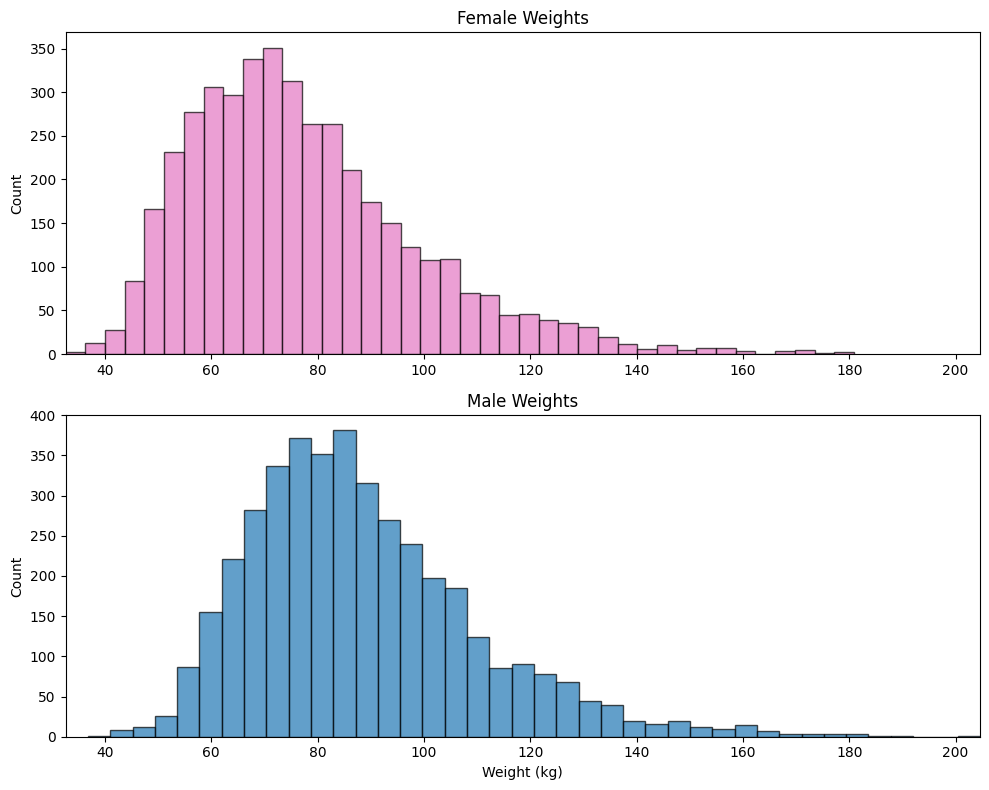

In [4]:
import matplotlib.pyplot as plt

# 1. Extract the weight columns (Index 0 based on previous step)
# We remove NaNs (Not a Number) to prevent plotting errors
male_weights = male[:, 0]
male_weights = male_weights[~np.isnan(male_weights)]

female_weights = female[:, 0]
female_weights = female_weights[~np.isnan(female_weights)]

# 2. Determine global min and max for the x-axis limits
# This ensures both plots share the exact same scale
global_min = min(np.min(male_weights), np.min(female_weights))
global_max = max(np.max(male_weights), np.max(female_weights))

# 3. Create the plot
plt.figure(figsize=(10, 8))

# Top Subfigure: Female Weights
plt.subplot(2, 1, 1)  # (rows, cols, index)
plt.hist(female_weights, bins=40, color='tab:pink', edgecolor='black', alpha=0.7)
plt.title('Female Weights')
plt.xlim(global_min, global_max)
plt.ylabel('Count')

# Bottom Subfigure: Male Weights
plt.subplot(2, 1, 2)
plt.hist(male_weights, bins=40, color='tab:blue', edgecolor='black', alpha=0.7)
plt.title('Male Weights')
plt.xlim(global_min, global_max)
plt.xlabel('Weight (kg)')
plt.ylabel('Count')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## 3. Comparative Analysis: Box-and-Whisker Plots
**Objective:**
To compare the central tendency, spread, and outliers of weight between males and females side-by-side.

**Interpretation Guide:**
The boxplot displays the Median (line inside the box), the Interquartile Range (the box itself), and outliers (points beyond the whiskers).

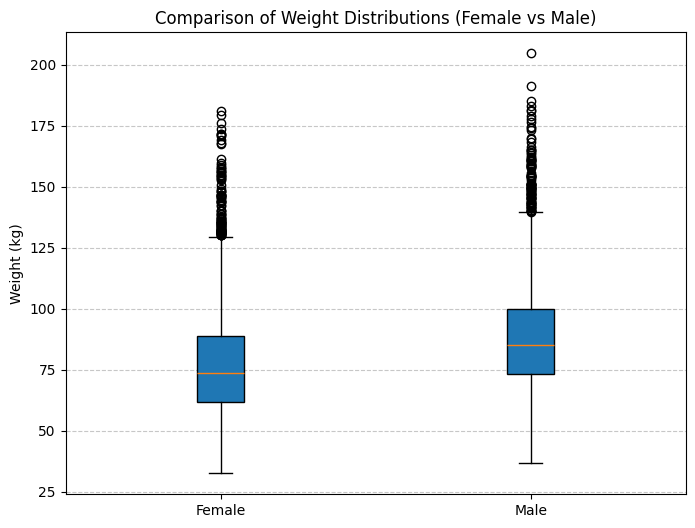

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Corrected parameter: used 'tick_labels' instead of 'labels'
plt.boxplot([female_weights, male_weights], 
            tick_labels=['Female', 'Male'], 
            patch_artist=True)

plt.title('Comparison of Weight Distributions (Female vs Male)')
plt.ylabel('Weight (kg)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## 4. Statistical Aggregates
**Objective:**
To quantify the properties of the distributions calculated above.

**Metrics Calculated:**
* **Measures of Location:** Mean, Median.
* **Measures of Dispersion:** Standard Deviation, Range (Min/Max).
* **Measures of Shape:** Skewness (asymmetry) and Kurtosis (tail heaviness).

In [7]:
import pandas as pd

# Convert the cleaned numpy arrays (from Step 3) to Pandas Series
# This gives us access to easy statistical methods
s_male = pd.Series(male_weights)
s_female = pd.Series(female_weights)

# Create a comparison dataframe
stats_comparison = pd.DataFrame({
    'Male': [
        s_male.mean(), 
        s_male.median(), 
        s_male.std(), 
        s_male.min(), 
        s_male.max(), 
        s_male.skew(), 
        s_male.kurtosis()
    ],
    'Female': [
        s_female.mean(), 
        s_female.median(), 
        s_female.std(), 
        s_female.min(), 
        s_female.max(), 
        s_female.skew(), 
        s_female.kurtosis()
    ]
}, index=['Mean', 'Median', 'Std Dev', 'Min', 'Max', 'Skewness', 'Kurtosis'])

# Display rounded results
print(stats_comparison.round(3))

             Male   Female
Mean       88.365   77.404
Median     85.000   73.600
Std Dev    21.422   21.545
Min        36.800   32.600
Max       204.600  180.900
Skewness    0.985    1.034
Kurtosis    1.478    1.404


## 5. Feature Engineering: Body Mass Index (BMI)
**Objective:**
To derive the Body Mass Index (BMI) for the female dataset.

**Formula:**
$$BMI = \frac{Weight (kg)}{Height (m)^2}$$

**Process:**
Height is converted from centimeters to meters before calculation. The resulting BMI vector is appended as the 8th column to the matrix.

In [8]:
# 1. Calculate BMI
# Weight is column 0, Height is column 1 (in cm)
weights_kg = female[:, 0]
heights_m = female[:, 1] / 100.0  # Convert cm to meters

bmi = weights_kg / (heights_m ** 2)

# 2. Add as the 8th column
# We use np.column_stack which automatically handles the reshaping of the 1D BMI array
female = np.column_stack((female, bmi))

# Verify
print("New female matrix shape:", female.shape)
print("First 3 BMI values:", female[:3, 7]) # Column index 7 is the 8th column

New female matrix shape: (4221, 8)
First 3 BMI values: [37.83504078 39.06972037 28.09265496]


## 6. Data Standardization (Z-Scores)
**Objective:**
To Standardize the female dataset to allow for comparison between variables with different units (e.g., cm vs kg).

**Methodology:**
Z-scores are calculated for every column:
$$Z = \frac{x - \mu}{\sigma}$$
Where $\mu$ is the mean and $\sigma$ is the standard deviation. This scales all data to have a Mean of 0 and a Std Dev of 1.

In [9]:
# 7. Standardize the female matrix (Z-scores)
# Formula: (x - mean) / std_dev
# We use nanmean and nanstd to ignore missing values during calculation

means = np.nanmean(female, axis=0)
stds = np.nanstd(female, axis=0)

# Broadcasting allows us to subtract the mean vector and divide by the std vector directly
zfemale = (female - means) / stds

# Verification
print("zfemale shape:", zfemale.shape)
print("Mean of columns (should be ~0):", np.nanmean(zfemale, axis=0).round(2))
print("Std of columns (should be ~1):", np.nanstd(zfemale, axis=0).round(2))

zfemale shape: (4221, 8)
Mean of columns (should be ~0): [-0.  0.  0.  0.  0.  0. -0.  0.]
Std of columns (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


## 7. Multivariate Analysis & Correlation
**Objective:**
To identify relationships between different anthropometric measurements.

**Visualizations:**
* **Pairplot:** A matrix of scatterplots to visualize linear and non-linear patterns.
* **Correlation Coefficients:**
    * **Pearson:** Measures linear correlation.
    * **Spearman:** Measures monotonic (rank-based) correlation.

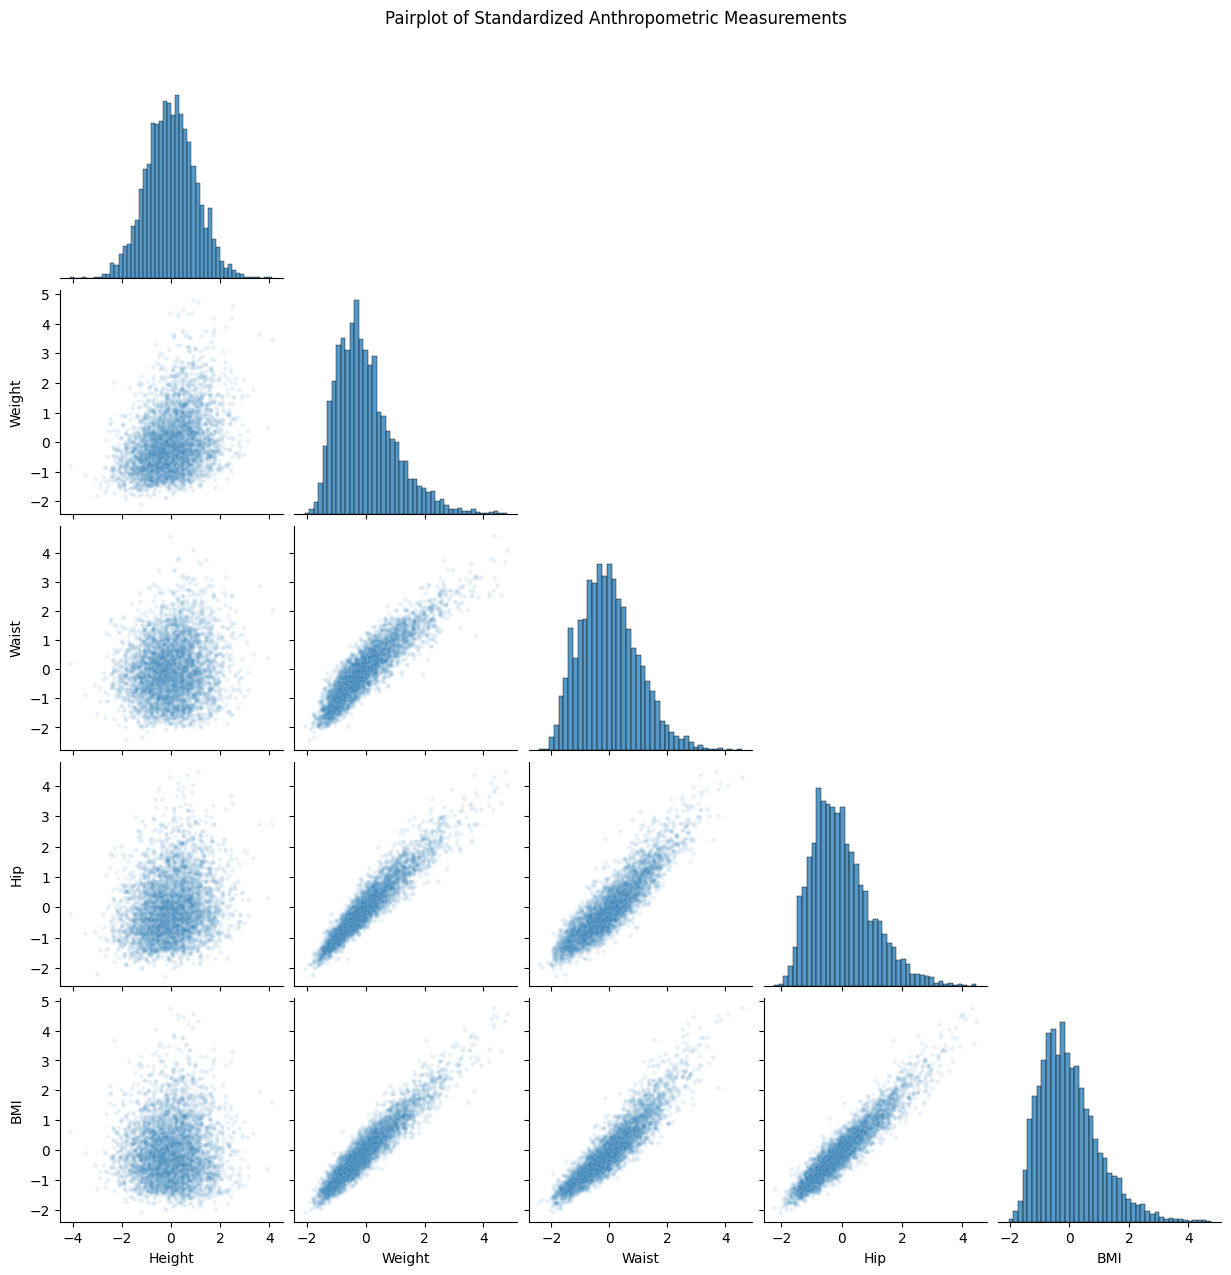

Pearson Correlation Coefficients:
        Height  Weight  Waist    Hip    BMI
Height   1.000   0.345  0.127  0.203  0.033
Weight   0.345   1.000  0.905  0.947  0.946
Waist    0.127   0.905  1.000  0.897  0.921
Hip      0.203   0.947  0.897  1.000  0.944
BMI      0.033   0.946  0.921  0.944  1.000

Spearman Correlation Coefficients:
        Height  Weight  Waist    Hip    BMI
Height   1.000   0.339  0.109  0.205  0.020
Weight   0.339   1.000  0.900  0.947  0.938
Waist    0.109   0.900  1.000  0.888  0.923
Hip      0.205   0.947  0.888  1.000  0.934
BMI      0.020   0.938  0.923  0.934  1.000


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Select specific columns from zfemale
# Indices: Height (1), Weight (0), Waist (6), Hip (5), BMI (7)
# Note: zfemale is a numpy array, so we slice by index
selected_indices = [1, 0, 6, 5, 7]
column_names = ['Height', 'Weight', 'Waist', 'Hip', 'BMI']

# Create a temporary DataFrame for plotting
df_z_subset = pd.DataFrame(zfemale[:, selected_indices], columns=column_names)

# 2. Draw Scatterplot Matrix (Pairplot)
# corner=True removes the redundant upper triangle
sns.pairplot(df_z_subset, plot_kws={'alpha': 0.1, 's': 10}, corner=True)
plt.suptitle('Pairplot of Standardized Anthropometric Measurements', y=1.02)
plt.show()

# 3. Compute Correlations
pearson_corr = df_z_subset.corr(method='pearson')
spearman_corr = df_z_subset.corr(method='spearman')

print("Pearson Correlation Coefficients:")
print(pearson_corr.round(3))

print("\nSpearman Correlation Coefficients:")
print(spearman_corr.round(3))

## 8. Advanced Health Metrics: WHtR and WHR
**Objective:**
To compute and visualize metrics that are better indicators of cardiovascular health than BMI alone.

**New Variables:**
1.  **Waist-to-Height Ratio (WHtR):** Indicates central obesity.
2.  **Waist-to-Hip Ratio (WHR):** Indicates body shape ("Apple" vs. "Pear").

The boxplot below compares these ratios across genders to highlight sexual dimorphism.

In [11]:
# --- Male Matrix Calculations ---
# Waist is col 6, Height is col 1, Hip is col 5
waist_m = male[:, 6]
height_m = male[:, 1]
hip_m = male[:, 5]

# Calculate ratios
whtr_m = waist_m / height_m
whr_m = waist_m / hip_m

# Append columns (Resulting shape: N x 9)
male = np.column_stack((male, whtr_m, whr_m))


# --- Female Matrix Calculations ---
# Column indices 0-6 are the same as male
waist_f = female[:, 6]
height_f = female[:, 1]
hip_f = female[:, 5]

# Calculate ratios
whtr_f = waist_f / height_f
whr_f = waist_f / hip_f

# Append columns (Resulting shape: N x 10, because it includes BMI)
female = np.column_stack((female, whtr_f, whr_f))

# Verify
print("New Male matrix shape:", male.shape)     # Expected: (Rows, 9)
print("New Female matrix shape:", female.shape) # Expected: (Rows, 10)

New Male matrix shape: (4081, 9)
New Female matrix shape: (4221, 10)


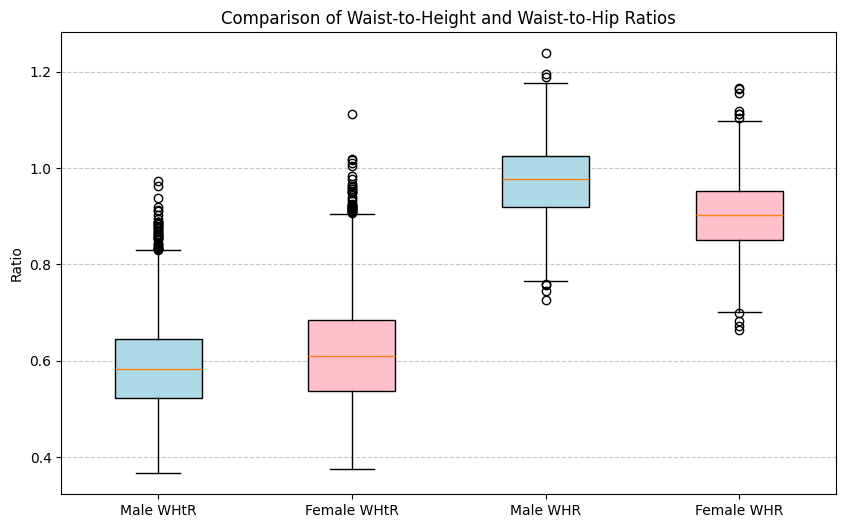

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract and clean the data (remove NaNs)
# Male Indices: 7=WHtR, 8=WHR
male_whtr = male[:, 7]
male_whtr = male_whtr[~np.isnan(male_whtr)]

male_whr = male[:, 8]
male_whr = male_whr[~np.isnan(male_whr)]

# Female Indices: 8=WHtR, 9=WHR (Index 7 is BMI)
female_whtr = female[:, 8]
female_whtr = female_whtr[~np.isnan(female_whtr)]

female_whr = female[:, 9]
female_whr = female_whr[~np.isnan(female_whr)]

# 2. Prepare data for plotting
data = [male_whtr, female_whtr, male_whr, female_whr]
labels = ['Male WHtR', 'Female WHtR', 'Male WHR', 'Female WHR']
colors = ['lightblue', 'pink', 'lightblue', 'pink']

# 3. Create the plot
plt.figure(figsize=(10, 6))
bplot = plt.boxplot(data, tick_labels=labels, patch_artist=True)

# Apply colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Comparison of Waist-to-Height and Waist-to-Hip Ratios')
plt.ylabel('Ratio')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### 11. Advantages and Disadvantages of Anthropometric Metrics

**1. Body Mass Index (BMI)**
* **Advantages:**
    * **Simplicity:** Requires only height and weight; easy to calculate and inexpensive.
    * **Standardization:** Global standard (WHO/CDC), making it easy to compare populations.
* **Disadvantages:**
    * **Ignores Body Composition:** Cannot distinguish between muscle mass and body fat (e.g., athletes may be misclassified as overweight).
    * **Ignores Fat Distribution:** Does not account for visceral (abdominal) fat, which is more dangerous.

**2. Waist-to-Height Ratio (WHtR)**
* **Advantages:**
    * **Health Risk Indicator:** Better at detecting central obesity and cardiovascular risk than BMI.
    * **Universal:** Generally valid across different ages, genders, and ethnicities.
* **Disadvantages:**
    * **Measurement Error:** It is harder to measure waist circumference consistently compared to simple weight/height.

**3. Waist-to-Hip Ratio (WHR)**
* **Advantages:**
    * **Body Shape:** Effectively identifies body shape ("Apple" vs. "Pear").
    * **Sexual Dimorphism:** Accounts for biological differences in fat storage between men and women.
* **Disadvantages:**
    * **False Negatives:** A person gaining weight proportionally in both waist and hips might maintain a "healthy" ratio despite being overweight.
    * **Skeletal Bias:** Heavily influenced by pelvic bone structure regardless of fat.

## 10. Extreme Value Analysis
**Objective:**
To inspect the standardized measurements (Z-scores) of the individuals with the lowest and highest BMI.

**Analysis:**
This helps identify the characteristics of outliers. For example, individuals with the highest BMI are expected to have Z-scores > +3.0 across weight and circumference measurements.

In [13]:
import pandas as pd

# 1. Clean the data (remove rows where BMI is NaN to ensure accurate sorting)
# We create a temporary cleaned version for this specific task
# Column 7 is BMI
valid_rows = ~np.isnan(zfemale[:, 7])
zfemale_clean = zfemale[valid_rows]

# 2. Get indices that would sort the array based on BMI (Col 7)
sorted_indices = np.argsort(zfemale_clean[:, 7])

# 3. Select the 5 lowest and 5 highest
# First 5 indices (Lowest BMI)
lowest_indices = sorted_indices[:5]
# Last 5 indices (Highest BMI)
highest_indices = sorted_indices[-5:]

# Combine them
chosen_indices = np.concatenate((lowest_indices, highest_indices))

# 4. Extract the rows
subset = zfemale_clean[chosen_indices]

# 5. Display as a DataFrame for readability
column_names = ['Weight', 'Height', 'ArmL', 'LegL', 'ArmC', 'HipC', 'WaistC', 'BMI']
df_subset = pd.DataFrame(subset, columns=column_names)

# Add a label column for clarity
df_subset.insert(0, 'Group', ['Lowest BMI']*5 + ['Highest BMI']*5)

print(df_subset.round(2))

         Group  Weight  Height  ArmL  LegL  ArmC  HipC  WaistC   BMI
0   Lowest BMI   -2.08   -1.22 -1.55 -1.17 -2.19 -2.04   -1.94 -2.05
1   Lowest BMI   -1.88   -0.19 -1.72  0.39 -2.44 -1.85   -2.06 -1.99
2   Lowest BMI   -1.54    1.81  0.63  0.57 -2.27 -1.68   -1.71 -1.97
3   Lowest BMI   -1.84   -0.26 -0.23  0.51 -2.30 -2.25   -1.86 -1.94
4   Lowest BMI   -1.61    0.89 -0.10  0.48 -2.21 -1.83   -1.71 -1.89
5  Highest BMI    4.25    0.29  1.86 -0.98  2.37  4.10    3.82  4.40
6  Highest BMI    4.46    0.50  1.69 -1.14  3.35  3.98    2.90  4.46
7  Highest BMI    4.35    0.28  2.84  1.94  4.37  3.92    3.75  4.51
8  Highest BMI    4.80    0.89  2.12  1.82  3.78  4.02    4.08  4.54
9  Highest BMI    4.36   -0.03 -0.06 -0.17  2.78  4.32    4.57  4.76
